In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
import jax
import ml_confs
import xarray as xr

from spectraformer.input_pipeline import preprocess_dataset, preprocess_dataset_raw

jax.config.update("jax_debug_nans", True)

maindir = Path('/home/dpoteryayev/SpectraFormer/Poisson check.ipynb').parent.resolve()

logdir = maindir / "logs"
ckptdir = maindir / "checkpoints"
# Check if logdir and ckptdir exist, if not create them
logdir.mkdir(parents=True, exist_ok=True)
ckptdir.mkdir(parents=True, exist_ok=True)

datadir = maindir / "data"

model_tag = "min8"  # CHOOSE ONE (.yaml file should exist)
                    # tag also can be found for already trained models in checkpoints folder

configsdir = maindir / "configs"
configsdir.mkdir(parents=True, exist_ok=True)

config_file_name = f"configs_{model_tag}.yaml"
config_file_path = configsdir / config_file_name

configs = ml_confs.from_file(config_file_path)
configs.tabulate()

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Key                    ┃ Value              ┃ Type      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ tag                    │ spectraformer:min8 │ str       │
│ embedding_dim          │ 64                 │ int       │
│ num_heads              │ 8                  │ int       │
│ num_layers             │ 2                  │ int       │
│ learning_rate          │ 0.0001             │ float     │
│ num_epochs             │ 600                │ int       │
│ batch_size             │ 19                 │ int       │
│ dropout_rate           │ 0.5                │ float     │
│ root_rng_seed          │ 0                  │ int       │
│ train_dataset          │ SiC_19x10x3        │ str       │
│ log_every_epochs       │ 5                  │ int       │
│ masked_interval_starts │ [1000, 2500]       │ list[int] │
│ masked_interval_ends   │ [1700, 2900]       │ list[int] │
└────────────────────────┴────────────────────┴───────────┘

In [2]:
# Load the full dataset
full_ds = preprocess_dataset(
    xr.load_dataarray(datadir / f"{configs.train_dataset}.nc")
) - 0.1

mean_values = full_ds.mean(
    dim=['spectra']
)

variance_values = full_ds.var(
    dim=['spectra']
)

std_values = full_ds.std(
    dim=['spectra']
)

scale_param_values = variance_values / mean_values

shape_param_values = mean_values**2 / std_values**2

full_ds

Dropped 0 spectra


<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[0.06321972, 0.06322556, 0.07688599, ..., 0.06697275, 0.07813979,
        0.08525848],
       [0.07789186, 0.06324255, 0.08054267, ..., 0.05904082, 0.07665442,
        0.07776609],
       [0.07257985, 0.06325956, 0.07146665, ..., 0.06568322, 0.07817971,
        0.07402785],
       ...,
       [0.02190699, 0.01672867, 0.01595614, ..., 0.02191288, 0.01717111,
        0.01904489],
       [0.01359051, 0.02230961, 0.0182329 , ..., 0.02026475, 0.02093749,
        0.01670395],
       [0.01026167, 0.0111595 , 0.02050487, ..., 0.01364431, 0.01529626,
        0.03782147]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4

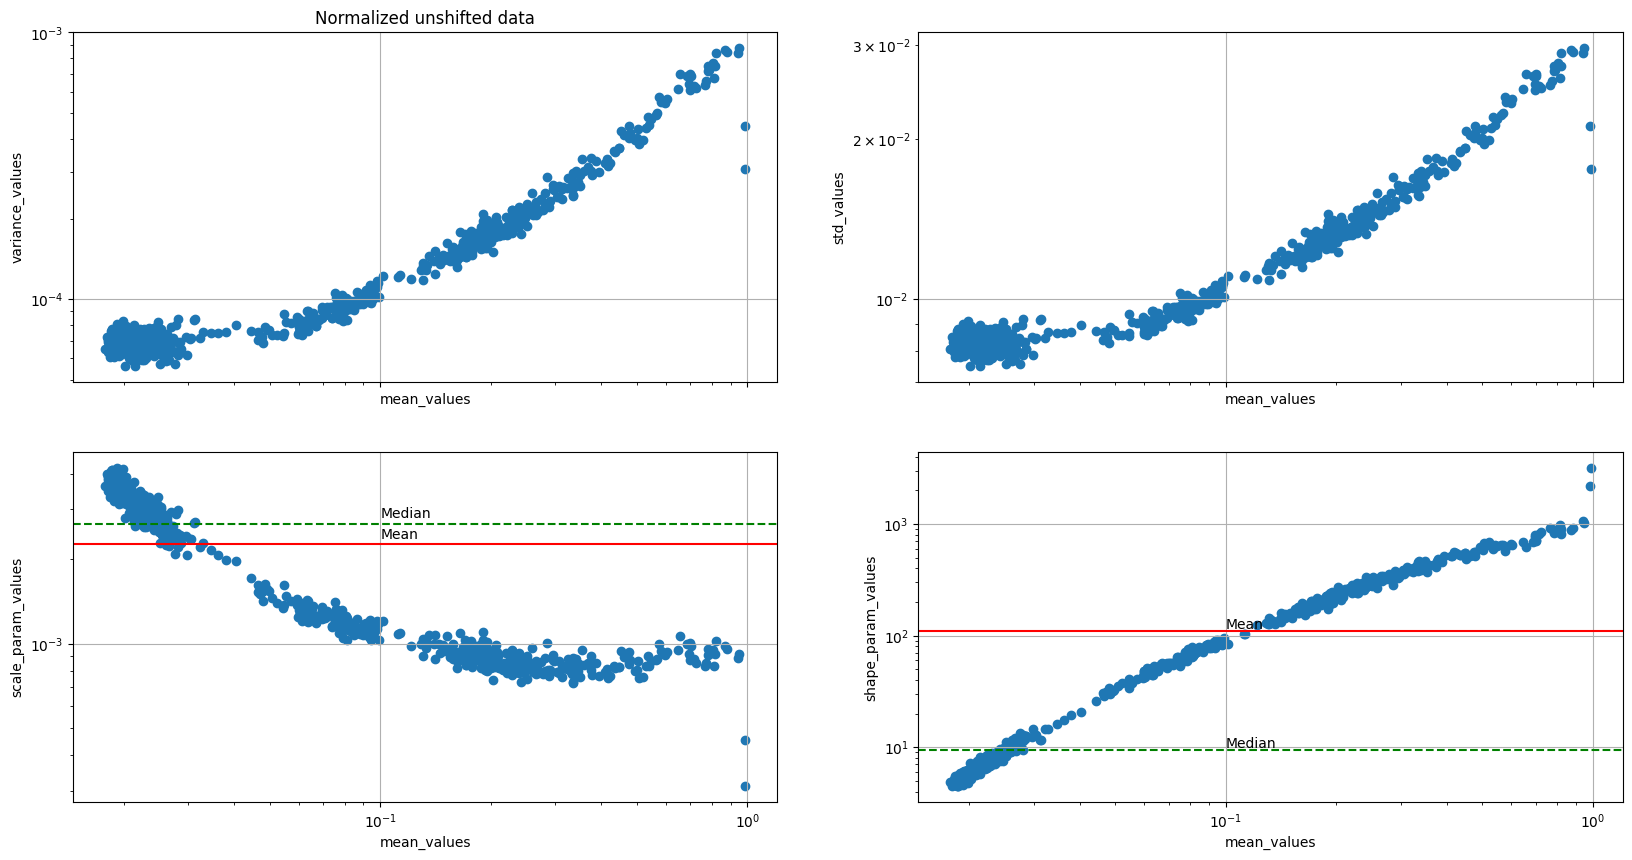

In [3]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean_values, y=variance_values)
axes[0,0].set_xlabel('mean_values')
axes[0,0].set_ylabel('variance_values')
axes[0,0].set_title('Normalized unshifted data')
axes[0,0].set_yscale('log')
axes[0,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,0].grid(visible=True, which='major', axis='both')

axes[0,1].scatter(x=mean_values, y=std_values)
axes[0,1].set_xlabel('mean_values')
axes[0,1].set_ylabel('std_values')
# axes[0,1].set_title('Normalized data')
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,1].grid(visible=True, which='major', axis='both')

axes[1,0].scatter(x=mean_values, y=scale_param_values)
axes[1,0].set_xlabel('mean_values')
axes[1,0].set_ylabel('scale_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,0].set_yscale('log')
axes[1,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,0].grid(visible=True, which='major', axis='both')
axes[1,0].axhline(y=scale_param_values.mean(), color='r', linestyle='-')
axes[1,0].annotate('Mean', ( 1e-1, 1.05*scale_param_values.mean()))
axes[1,0].axhline(y=scale_param_values.median(), color='g', linestyle='--')
axes[1,0].annotate('Median', ( 1e-1, 1.05*scale_param_values.median()))

axes[1,1].scatter(x=mean_values, y=shape_param_values)
axes[1,1].set_xlabel('mean_values')
axes[1,1].set_ylabel('shape_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,1].set_yscale('log')
axes[1,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,1].grid(visible=True, which='major', axis='both')
axes[1,1].axhline(y=shape_param_values.mean(), color='r', linestyle='-')
axes[1,1].annotate('Mean', ( 1e-1, 1.05*shape_param_values.mean()))
axes[1,1].axhline(y=shape_param_values.median(), color='g', linestyle='--')
axes[1,1].annotate('Median', ( 1e-1, 1.05*shape_param_values.median()))

plt.show()

In [4]:
dataset2 = preprocess_dataset(
    xr.load_dataarray(datadir / f"SiC_100x10.nc")
) - 0.1
dataset2

Dropped 19 spectra


<xarray.DataArray (wave_number: 1015, spectra: 981)>
array([[0.06254566, 0.08294691, 0.05638902, ..., 0.06738384, 0.0543037 ,
        0.0697908 ],
       [0.10074277, 0.08296624, 0.07906306, ..., 0.08455541, 0.06925775,
        0.09019273],
       [0.06735003, 0.0935588 , 0.07774933, ..., 0.09560624, 0.0892    ,
        0.07109781],
       ...,
       [0.01958555, 0.02975454, 0.03703815, ..., 0.07193183, 0.04866816,
        0.02709968],
       [0.04343844, 0.04791769, 0.03038707, ..., 0.06735465, 0.05490049,
        0.06212035],
       [0.03449549, 0.0759778 , 0.02705697, ..., 0.05816993, 0.04867932,
        0.04461304]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 99 99 99 99 99 99 99 99
  * X_1          (spectra) int64 0 1 2 3 4 5 6 7 8 9 0 ... 9 0 1 2 3 4 5 6 7 8 9

In [5]:
ds_1 = full_ds.reset_index("spectra", drop=True)
ds_2 = dataset2.reset_index("spectra", drop=True)
combined_ds = xr.concat([ds_1, ds_2], dim="spectra", join="outer")
combined_ds = combined_ds.fillna(-2)
combined_ds

<xarray.DataArray (wave_number: 2030, spectra: 1551)>
array([[-2.        , -2.        , -2.        , ...,  0.06738384,
         0.0543037 ,  0.0697908 ],
       [ 0.06321972,  0.06322556,  0.07688599, ..., -2.        ,
        -2.        , -2.        ],
       [-2.        , -2.        , -2.        , ...,  0.08455541,
         0.06925775,  0.09019273],
       ...,
       [ 0.01359051,  0.02230961,  0.0182329 , ..., -2.        ,
        -2.        , -2.        ],
       [-2.        , -2.        , -2.        , ...,  0.05816993,
         0.04867932,  0.04461304],
       [ 0.01026167,  0.0111595 ,  0.02050487, ..., -2.        ,
        -2.        , -2.        ]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.278e+03 ... 2.82e+03 2.82e+03
Dimensions without coordinates: spectra

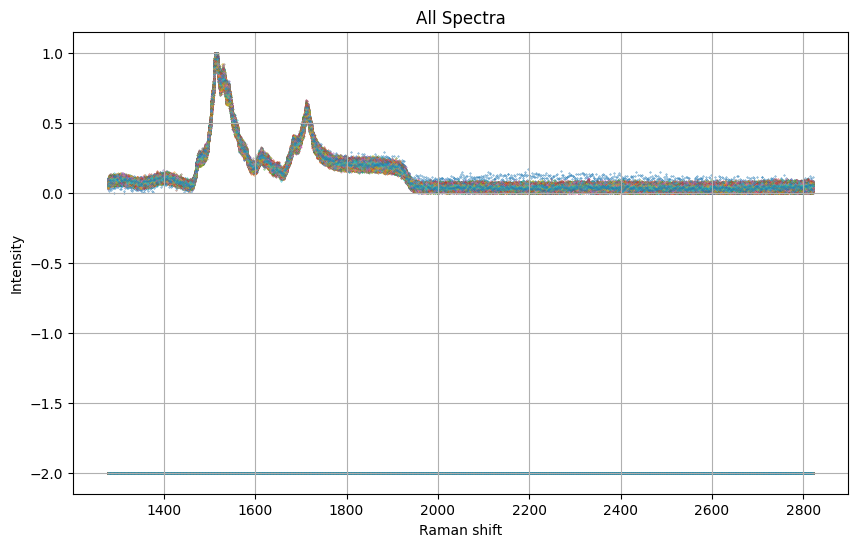

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(combined_ds.spectra.size):
    ax.scatter(combined_ds["wave_number"], combined_ds.isel(spectra=i), alpha=1, s=0.1)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra')

ax.grid(visible=True, which='both', axis='both')

plt.show()

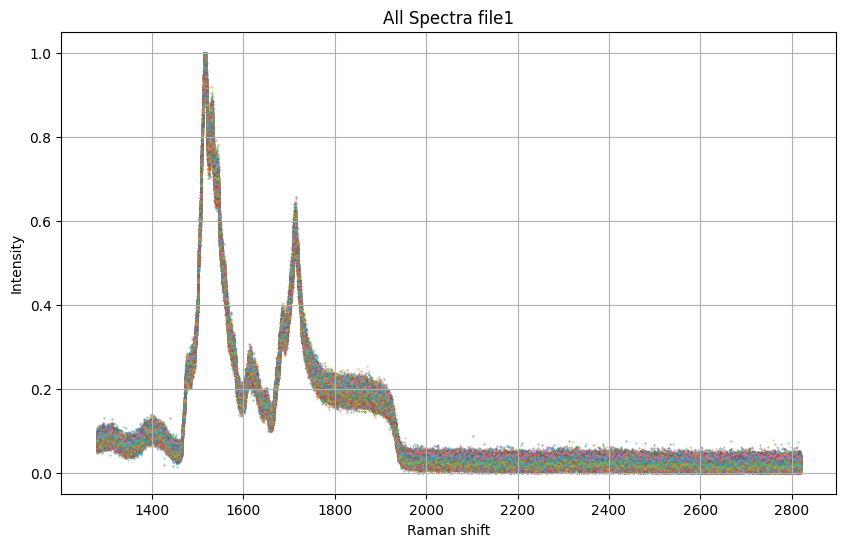

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(ds_1.spectra.size):
    ax.scatter(ds_1["wave_number"], ds_1.isel(spectra=i), alpha=1, s=0.1)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra file1')

ax.grid(visible=True, which='both', axis='both')

plt.show()

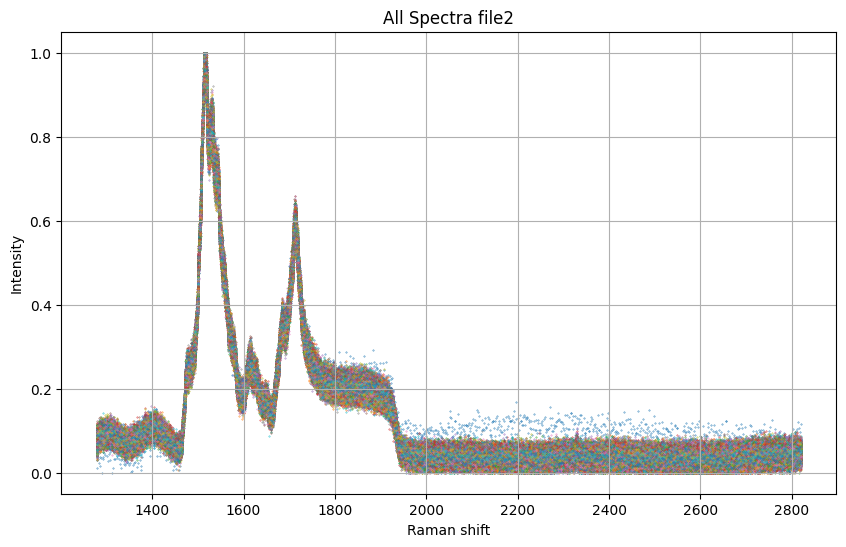

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(ds_2.spectra.size):
    ax.scatter(ds_2["wave_number"], ds_2.isel(spectra=i), alpha=1, s=0.1)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra file2')

ax.grid(visible=True, which='both', axis='both')

plt.show()

In [9]:
mean_values2 = ds_2.mean(
    dim=['spectra']
)

variance_values2 = ds_2.var(
    dim=['spectra']
)

std_values2 = ds_2.std(
    dim=['spectra']
)

scale_param_values2 = variance_values2 / mean_values2

shape_param_values2 = mean_values2**2 / std_values2**2

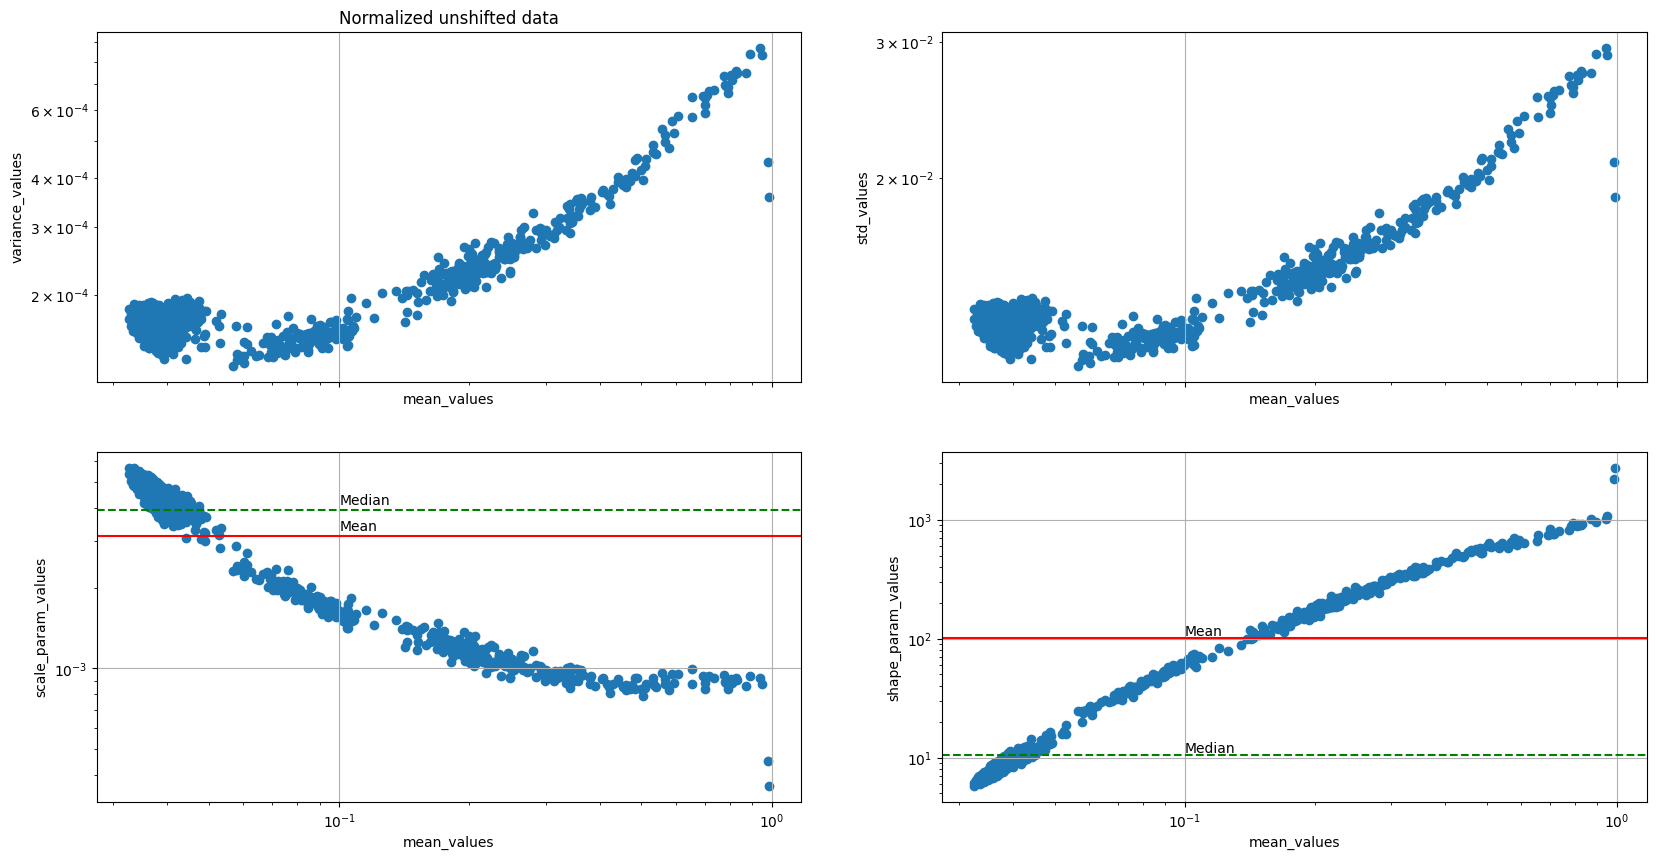

In [10]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean_values2, y=variance_values2)
axes[0,0].set_xlabel('mean_values')
axes[0,0].set_ylabel('variance_values')
axes[0,0].set_title('Normalized unshifted data')
axes[0,0].set_yscale('log')
axes[0,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,0].grid(visible=True, which='major', axis='both')

axes[0,1].scatter(x=mean_values2, y=std_values2)
axes[0,1].set_xlabel('mean_values')
axes[0,1].set_ylabel('std_values')
# axes[0,1].set_title('Normalized data')
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,1].grid(visible=True, which='major', axis='both')

axes[1,0].scatter(x=mean_values2, y=scale_param_values2)
axes[1,0].set_xlabel('mean_values')
axes[1,0].set_ylabel('scale_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,0].set_yscale('log')
axes[1,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,0].grid(visible=True, which='major', axis='both')
axes[1,0].axhline(y=scale_param_values2.mean(), color='r', linestyle='-')
axes[1,0].annotate('Mean', ( 1e-1, 1.05*scale_param_values2.mean()))
axes[1,0].axhline(y=scale_param_values2.median(), color='g', linestyle='--')
axes[1,0].annotate('Median', ( 1e-1, 1.05*scale_param_values2.median()))

axes[1,1].scatter(x=mean_values2, y=shape_param_values2)
axes[1,1].set_xlabel('mean_values')
axes[1,1].set_ylabel('shape_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,1].set_yscale('log')
axes[1,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,1].grid(visible=True, which='major', axis='both')
axes[1,1].axhline(y=shape_param_values2.mean(), color='r', linestyle='-')
axes[1,1].annotate('Mean', ( 1e-1, 1.05*shape_param_values2.mean()))
axes[1,1].axhline(y=shape_param_values2.median(), color='g', linestyle='--')
axes[1,1].annotate('Median', ( 1e-1, 1.05*shape_param_values2.median()))

plt.show()

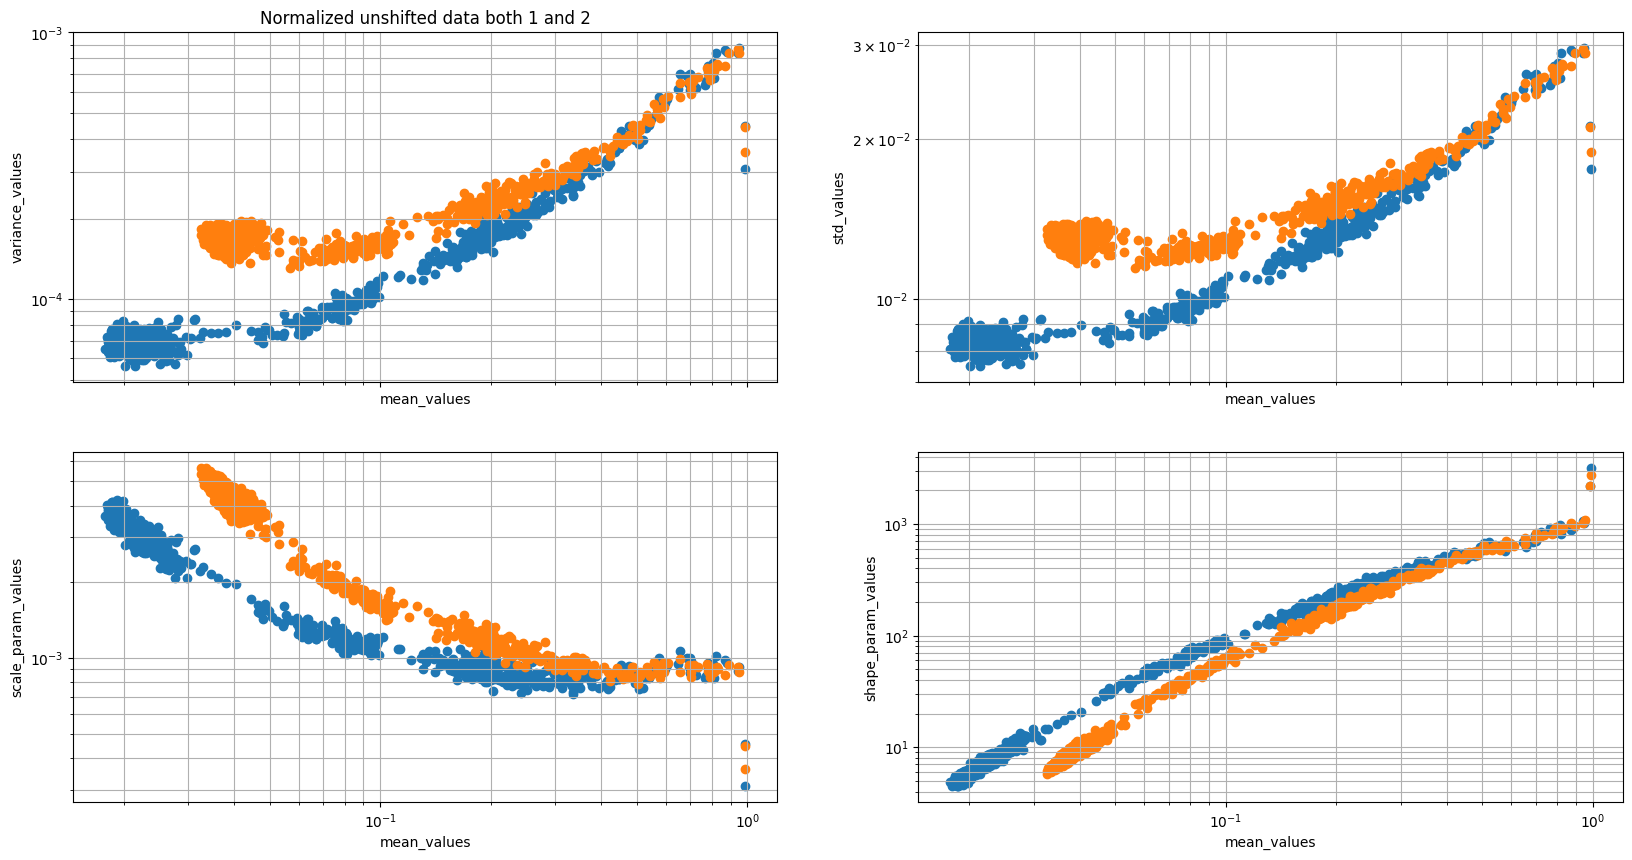

In [11]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean_values, y=variance_values)
axes[0,0].scatter(x=mean_values2, y=variance_values2)
axes[0,0].set_xlabel('mean_values')
axes[0,0].set_ylabel('variance_values')
axes[0,0].set_title('Normalized unshifted data both 1 and 2')
axes[0,0].set_yscale('log')
axes[0,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].scatter(x=mean_values, y=std_values)
axes[0,1].scatter(x=mean_values2, y=std_values2)
axes[0,1].set_xlabel('mean_values')
axes[0,1].set_ylabel('std_values')
# axes[0,1].set_title('Normalized data')
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,1].grid(visible=True, which='both', axis='both')

axes[1,0].scatter(x=mean_values, y=scale_param_values)
axes[1,0].scatter(x=mean_values2, y=scale_param_values2)
axes[1,0].set_xlabel('mean_values')
axes[1,0].set_ylabel('scale_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,0].set_yscale('log')
axes[1,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,0].grid(visible=True, which='both', axis='both')
# axes[1,0].axhline(y=scale_param_values2.mean(), color='r', linestyle='-')
# axes[1,0].annotate('Mean', ( 1e-1, 1.05*scale_param_values2.mean()))
# axes[1,0].axhline(y=scale_param_values2.median(), color='g', linestyle='--')
# axes[1,0].annotate('Median', ( 1e-1, 1.05*scale_param_values2.median()))

axes[1,1].scatter(x=mean_values, y=shape_param_values)
axes[1,1].scatter(x=mean_values2, y=shape_param_values2)
axes[1,1].set_xlabel('mean_values')
axes[1,1].set_ylabel('shape_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,1].set_yscale('log')
axes[1,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,1].grid(visible=True, which='both', axis='both')
# axes[1,1].axhline(y=shape_param_values2.mean(), color='r', linestyle='-')
# axes[1,1].annotate('Mean', ( 1e-1, 1.05*shape_param_values2.mean()))
# axes[1,1].axhline(y=shape_param_values2.median(), color='g', linestyle='--')
# axes[1,1].annotate('Median', ( 1e-1, 1.05*shape_param_values2.median()))

plt.show()

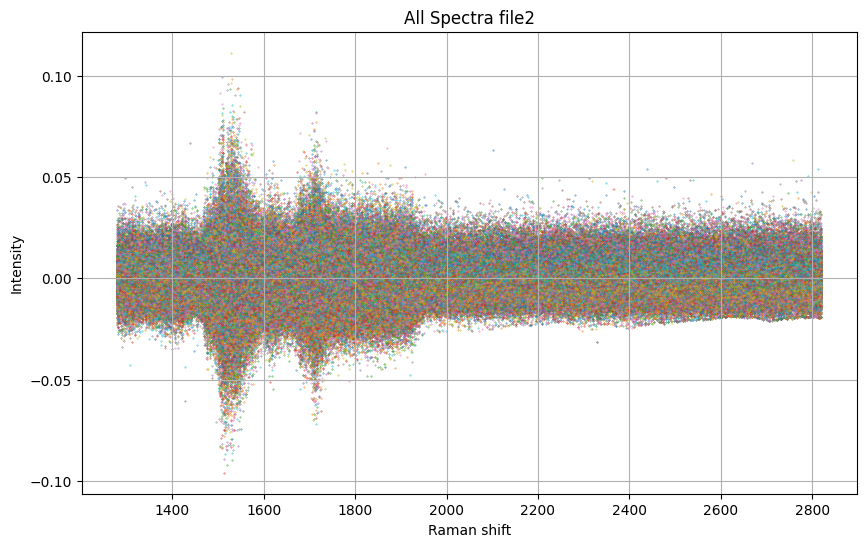

In [12]:
meancheck = ds_1 - ds_1.mean(dim=['spectra'])
fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(meancheck.spectra.size):
    ax.scatter(meancheck["wave_number"], meancheck.isel(spectra=i), alpha=1, s=0.1)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra file2')

ax.grid(visible=True, which='both', axis='both')

plt.show()

In [13]:
def my_statistics(
    dataset,
    dim: str = 'spectra'
    ):
    exp_val = dataset.mean(dim=[dim])
    variance = dataset.var(dim=[dim])
    std = dataset.std(dim=[dim])
    z1 = (dataset - exp_val)/std
    skewness = (z1**3).mean(dim=[dim])
    kurtosis = (z1**4).mean(dim=[dim])
    
    return exp_val, variance, std, skewness, kurtosis

In [16]:
mean1 , var1, std1, skew1, kurt1 = my_statistics(ds_1)
mean2 , var2, std2, skew2, kurt2 = my_statistics(ds_2)
print(skew1)
print(kurt1)

<xarray.DataArray (wave_number: 1015)>
array([0.34454645, 0.1155957 , 0.24360064, ..., 0.53538707, 0.60161758,
       0.47515322])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
<xarray.DataArray (wave_number: 1015)>
array([3.28624519, 2.95513412, 3.27380021, ..., 3.61703528, 3.49706157,
       3.206646  ])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03


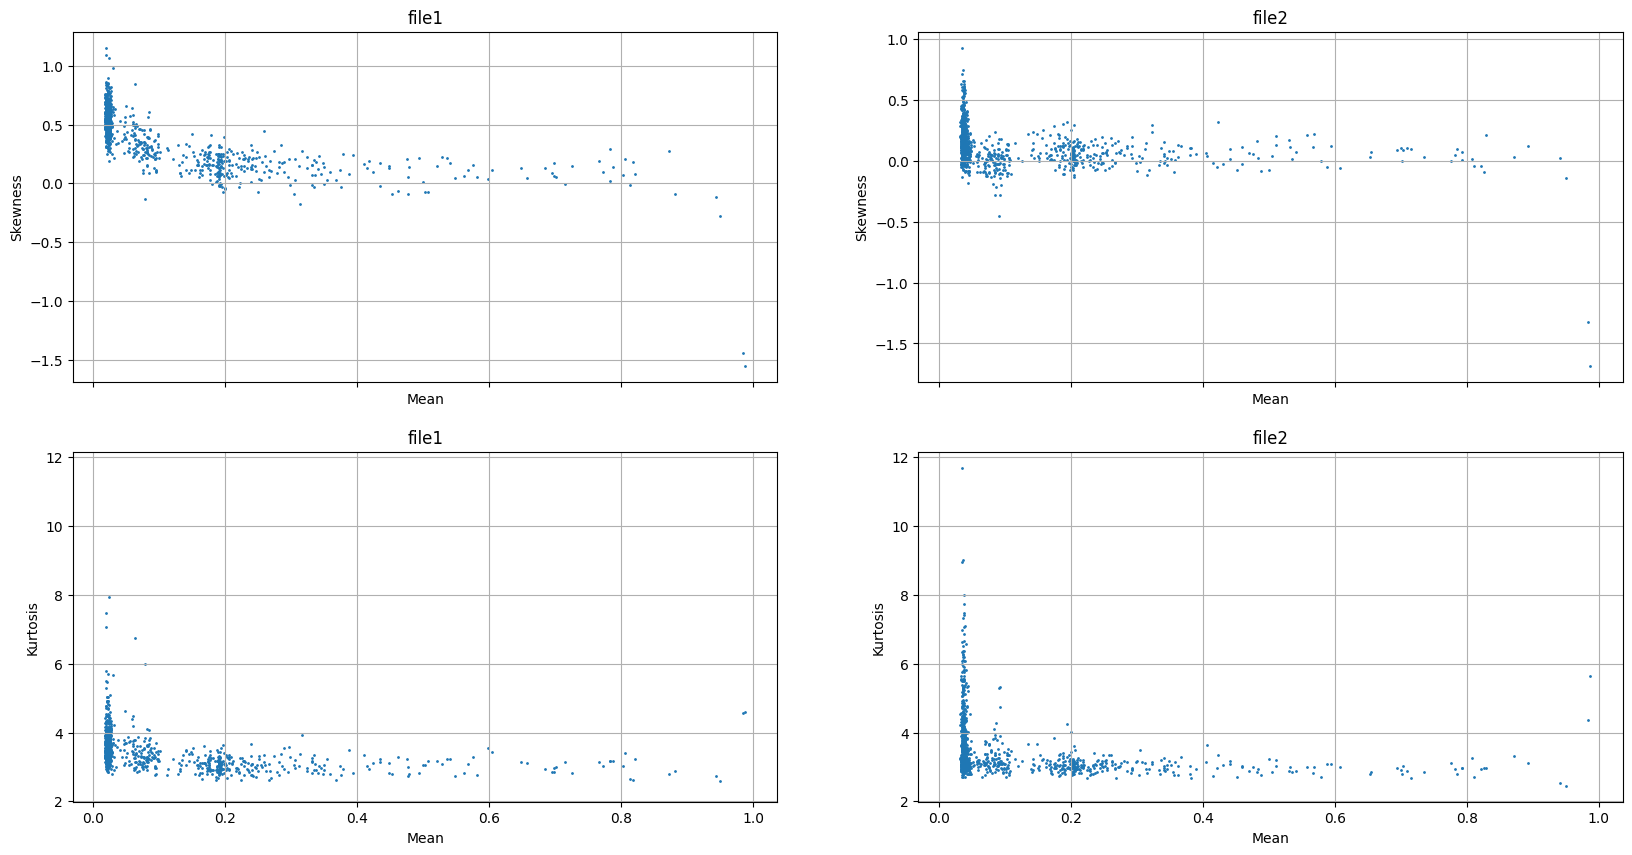

In [19]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean1, y=skew1, alpha=1, s=1)
axes[0,0].set_xlabel('Mean')
axes[0,0].set_ylabel('Skewness')
axes[0,0].set_title('file1')
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].scatter(x=mean2, y=skew2, alpha=1, s=1)
axes[0,1].set_xlabel('Mean')
axes[0,1].set_ylabel('Skewness')
axes[0,1].set_title('file2')
axes[0,1].grid(visible=True, which='both', axis='both')


axes[1,0].scatter(x=mean1, y=kurt1, alpha=1, s=1)
axes[1,0].set_xlabel('Mean')
axes[1,0].set_ylabel('Kurtosis')
axes[1,0].set_title('file1')
axes[1,0].grid(visible=True, which='both', axis='both')

axes[1,1].scatter(x=mean2, y=kurt2, alpha=1, s=1)
axes[1,1].set_xlabel('Mean')
axes[1,1].set_ylabel('Kurtosis')
axes[1,1].set_title('file2')
axes[1,1].grid(visible=True, which='both', axis='both')
axes[1,1].sharey(axes[1,0])

plt.show()